In [1]:
import json
from matplotlib.colors import ListedColormap
import sys
import os
from pathlib import Path

# Add the project root (or current file directory)
sys.path.append(str(Path(os.getcwd()).resolve().parent))

from touch_detection_alg.pipeline import compute_depth

IDX = 0
GREEN = ListedColormap([[0, 0, 0, 0], [0, 1, 0, 1]])
RED = ListedColormap([[0, 0, 0, 0], [1, 0, 0, 1]])
YELLOW = ListedColormap([[0, 0, 0, 0], [1, 1, 0, 1]])
BLUE = ListedColormap([[0, 0, 0, 0], [0, 0, 1, 1]])

YELLOW_H_WHITE = ListedColormap([[1, 1, 1, 0.5], [1, 1, 0, 1]])
BLUE_H_WHITE = ListedColormap([[1, 1, 1, 0.5], [0, 0, 1, 1]])
GREEN_WHITE = ListedColormap([[1, 1, 1, 1], [0, 1, 0, 1]])

In [4]:
json_file = "/scratch-shared/dotero/greatest_hits/annotations/train.json"

{
    "image_path": "/gpfs/scratch1/shared/dotero/greatest_hits/frames/2015-02-16-17-54-47_denoised/frame_000655.jpg",
    "audio_path": "/gpfs/scratch1/shared/dotero/greatest_hits/vis-data-256/vis-data-256/2015-02-16-17-54-47_denoised.wav",
    "type": "no-touch",
    "material": null,
    "action": null,
    "video_id": "2015-02-16-17-54-47_denoised",
    "frame_idx": 655,
    "timestamp_s": 21.860928,
    "stick_mask_path": "/scratch-shared/dotero/greatest_hits/masks/2015-02-16-17-54-47_denoised/frame_000655_stick.png",
    "object_mask_path": "/scratch-shared/dotero/greatest_hits/masks/2015-02-16-17-54-47_denoised/frame_000655_object.png",
    "target_path": "/scratch-shared/dotero/greatest_hits/masks/2015-02-16-17-54-47_denoised/frame_000655_touch.png",
    "depth_path": "/scratch-shared/dotero/greatest_hits/masks/2015-02-16-17-54-47_denoised/frame_000655_depth.png",
    "depth_touch": null,
    "x_touch": null,
    "y_touch": null,
    "object_coverage": 0.5432514391447368,
    "

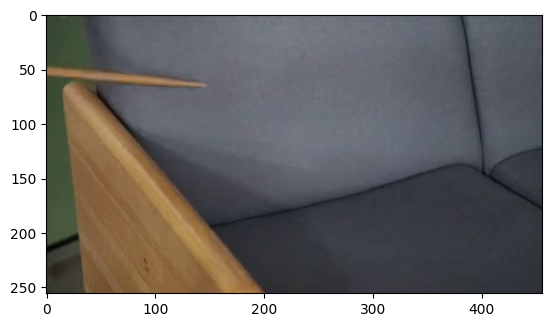

In [5]:
IDX = 400
with open(json_file, 'r') as file:
    gh_data = json.load(file)
    image_entry = gh_data[IDX]

print(json.dumps(image_entry, indent=4))
import matplotlib.pyplot as plt
plt.imshow(plt.imread(image_entry["image_path"]))
# good: 73, 30, 148, 175, 222, 275, 300, 340, 400

In [5]:
import matplotlib.pyplot as plt
CMAP = ListedColormap([0,0,0,0],[0,1,0,1])
def save_hits_images(idx, data):
    image_entry = data[idx]
    image = image_entry["image_path"]
    stick_mask = image_entry["stick_mask_path"]
    obj_mask = image_entry["object_mask_path"]
    touch_mask = image_entry["target_path"]
    
    # original image 
    plt.imshow(plt.imread(image))
    plt.axis('off')
    plt.savefig(f"{idx}_gh_original.png", bbox_inches='tight', pad_inches=0, transparent=True)
    plt.show()
    
    # image with masks
    plt.imshow(plt.imread(image))
    plt.imshow(plt.imread(stick_mask), alpha=0.5, cmap=YELLOW)
    plt.imshow(plt.imread(obj_mask), alpha=0.5, cmap=BLUE)
    plt.axis('off')
    plt.savefig(f"{idx}_gh_masks.png", bbox_inches='tight', pad_inches=0, transparent=True)
    plt.show()
    
    
    # impage with POT
    plt.imshow(plt.imread(image))
    plt.imshow(plt.imread(touch_mask), alpha=0.5, cmap=GREEN)
    plt.axis('off')
    plt.savefig(f"{idx}_gh_touch.png", bbox_inches='tight', pad_inches=0, transparent=True)
    plt.show()
    
    depth = compute_depth(plt.imread(image), guided_filter=False)
    plt.imshow(depth, cmap = 'inferno')
    plt.axis('off')
    plt.savefig(f"{idx}_gh_depth.png", bbox_inches='tight', pad_inches=0, transparent=True)
    plt.show()
    
    
# 400 shiit
# 602/702 good
# save_hits_images(702, gh_data)


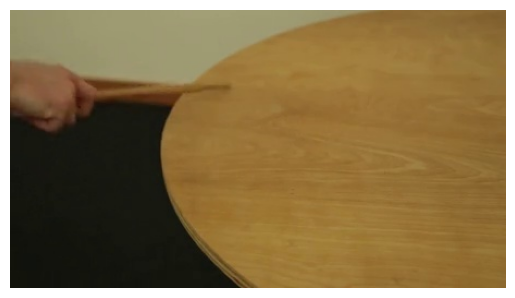

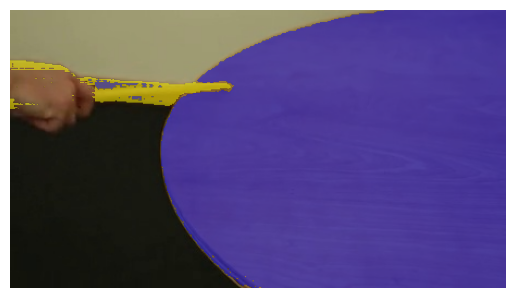

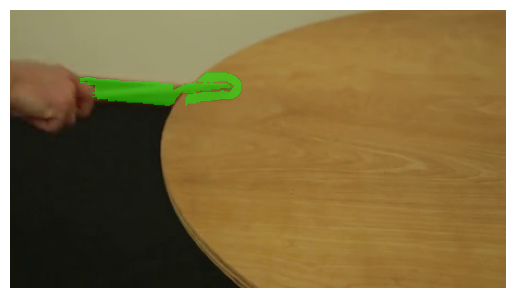

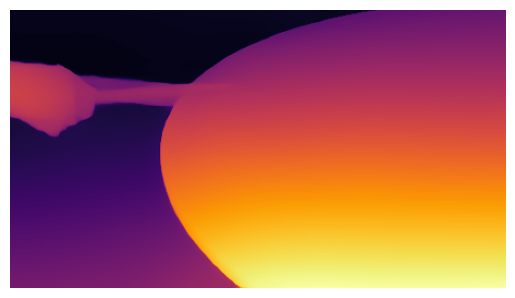

In [7]:
idx_list = [800]
for i in idx_list:
    save_hits_images(i, gh_data)

{
    "image_path": "/gpfs/scratch1/shared/dotero/epic_kitchen/frames/P01_01/P01_01_frame_0000045539.jpg",
    "hand_mask_path": "/gpfs/scratch1/shared/dotero/epic_kitchen/masks/P01_01/P01_01_frame_0000045539_p0_hand.png",
    "object_mask_path": "/gpfs/scratch1/shared/dotero/epic_kitchen/masks/P01_01/P01_01_frame_0000045539_p0_object.png",
    "target_path": "/gpfs/scratch1/shared/dotero/epic_kitchen/masks/P01_01/P01_01_frame_0000045539_p0_touch.png",
    "type": "touch",
    "video_id": "P01_01",
    "object_name": "salt",
    "frame_idx": 45539,
    "audio_timestamp_sec": 910.78,
    "audio_path": "",
    "touch_mask_path": "/gpfs/scratch1/shared/dotero/epic_kitchen/masks/P01_01/P01_01_frame_0000045539_p0_touch.png",
    "depth_path": "/gpfs/scratch1/shared/dotero/epic_kitchen/masks/P01_01/P01_01_frame_0000045539_p0_depth.png",
    "object_coverage": 0.01224633487654321,
    "x_touch": 2,
    "y_touch": 4,
    "depth_touch": 154.18287658691406,
    "general_class": "Food",
    "gh_c

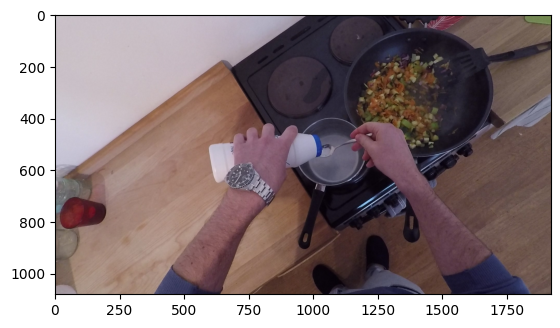

In [25]:
# good 70, 71, 72,73
IDX =73
epic_kitchen_file = "/scratch-shared/dotero/epic_kitchen/annotations/val.json"
with open(epic_kitchen_file, 'r') as file:
    epic_kitchen_data = json.load(file)
    epic_kitchen_image_entry = epic_kitchen_data[IDX]

print(json.dumps(epic_kitchen_image_entry, indent=4))
import matplotlib.pyplot as plt
plt.imshow(plt.imread(epic_kitchen_image_entry["image_path"]))

In [29]:
def save_epic_kitchen_images(idx, data):
    image_entry = data[idx]
    image = image_entry["image_path"]
    hand_mask = image_entry["hand_mask_path"]
    obj_mask = image_entry["object_mask_path"]
    touch_mask = image_entry["target_path"]

    new_touch_mask = image_entry["touch_mask_path"]
    
    
    # original image 
    plt.imshow(plt.imread(image))
    plt.axis('off')
    # plt.savefig(f"{idx}_ep_original.png", bbox_inches='tight', pad_inches=0, transparent=True)
    plt.show()
    
    # image with masks
    plt.imshow(plt.imread(image))
    plt.imshow(plt.imread(hand_mask), alpha=0.5, cmap=YELLOW)
    plt.imshow(plt.imread(obj_mask), alpha=0.5, cmap=BLUE)
    plt.axis('off')
    # plt.savefig(f"{idx}_ep_masks.png", bbox_inches='tight', pad_inches=0, transparent=True)
    plt.show()
    
    # impage with POT
    plt.imshow(plt.imread(image))
    plt.imshow(plt.imread(touch_mask), alpha=0.5, cmap=GREEN)
    plt.axis('off')
    # plt.savefig(f"{idx}_ep_touch.png",bbox_inches='tight', pad_inches=0, transparent=True)
    plt.show()

     # impage with POT refined
    plt.imshow(plt.imread(image))
    plt.imshow(plt.imread(new_touch_mask), alpha=0.5, cmap=GREEN)
    plt.axis('off')
    # plt.savefig(f"{idx}_ep_touch.png",bbox_inches='tight', pad_inches=0, transparent=True)
    plt.show()
    
    # depth = compute_depth(plt.imread(image), guided_filter=False)
    # plt.imshow(depth, cmap = 'inferno')
    # plt.axis('off')
    # # plt.savefig(f"{idx}_ep_depth.png", bbox_inches='tight', pad_inches=0, transparent=True)
    # plt.show()
    

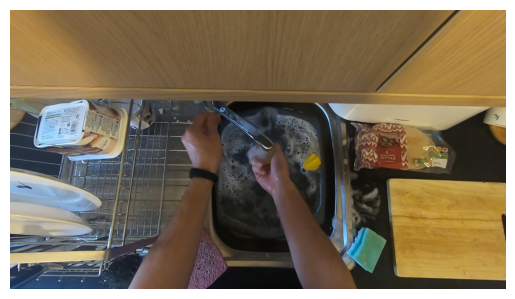

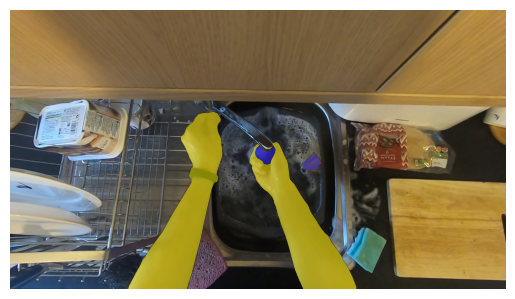

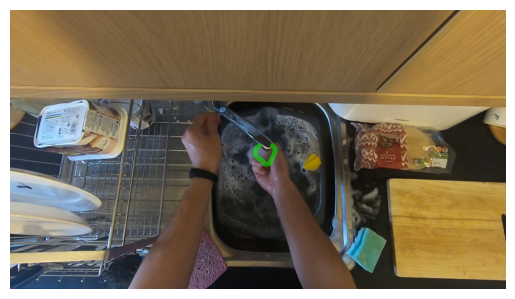

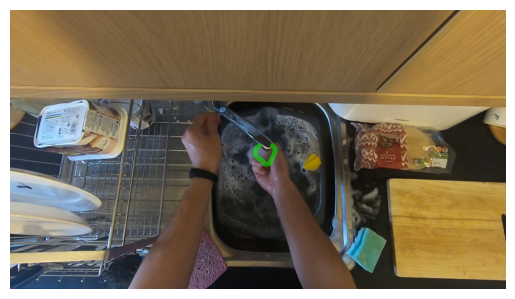

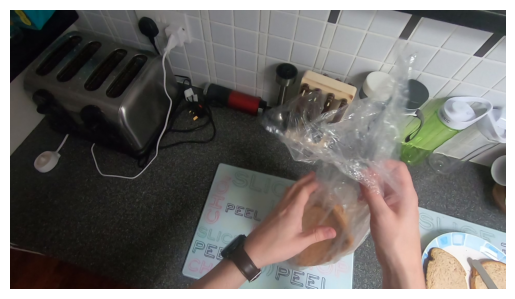

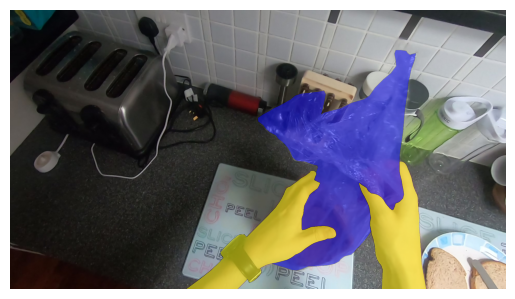

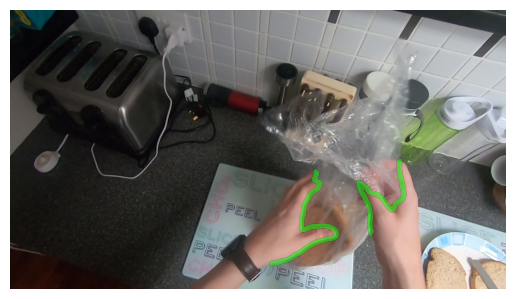

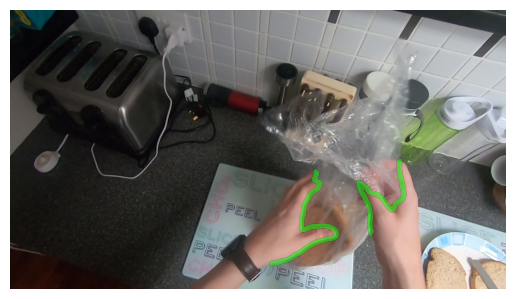

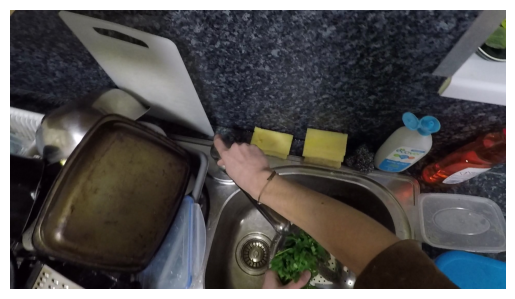

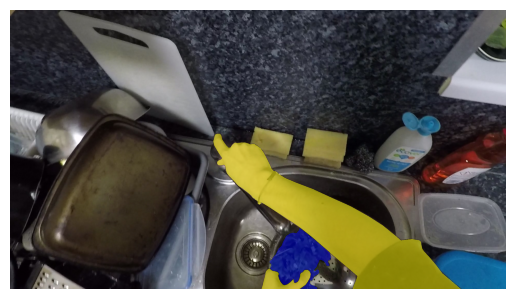

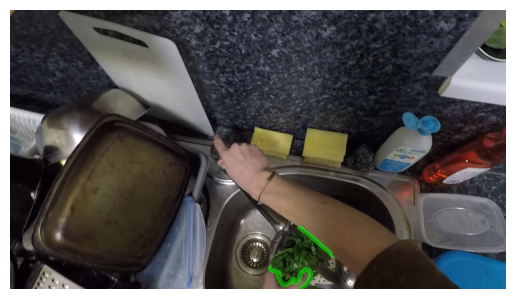

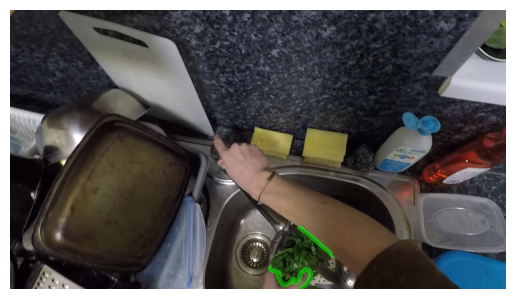

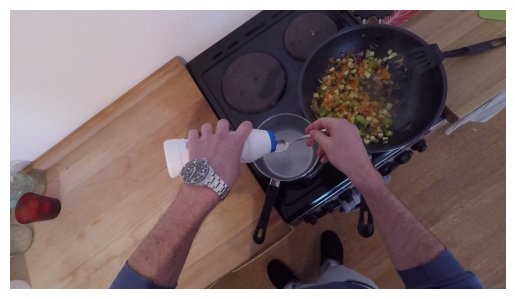

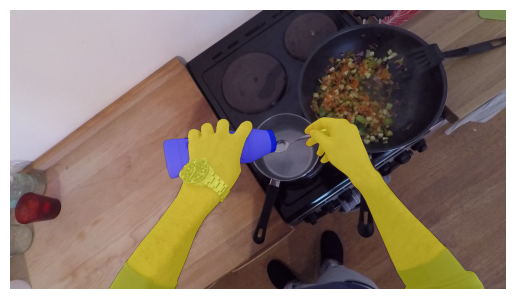

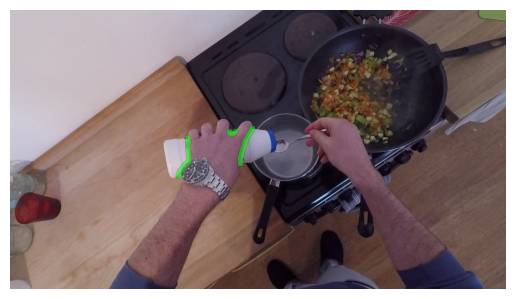

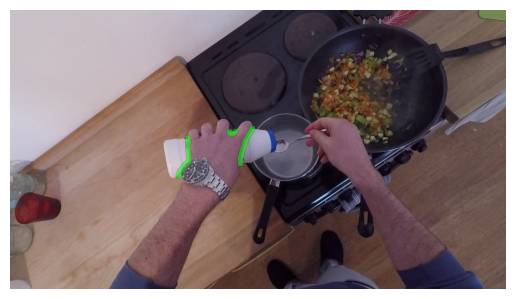

In [30]:
# save_epic_kitchen_images(3, data = epic_kitchen_data, dilated=False)

# good for touch: 33, 56, 96
# good for no touch: 99, 2873

idx_list = [70, 71, 72,73]
for i in idx_list:
    save_epic_kitchen_images(i, data = epic_kitchen_data)

{
    "image_path": "/gpfs/scratch1/shared/dotero/kubric/frames/8285/frame_000006.jpg",
    "object1_mask_path": "/gpfs/scratch1/shared/dotero/kubric/masks/8285/frame_000006_object1.png",
    "object2_mask_path": "/gpfs/scratch1/shared/dotero/kubric/masks/8285/frame_000006_object2.png",
    "target_path": "/gpfs/scratch1/shared/dotero/kubric/masks/8285/frame_000006_touch.png",
    "depth_path": "/gpfs/scratch1/shared/dotero/kubric/masks/8285/frame_000006_depth.png",
    "type": "touch",
    "video_id": "8285",
    "object_name": "small_yellow_metal_cylinder__large_green_rubber_cube",
    "object1_label": "small yellow metal cylinder",
    "object2_label": "large green rubber cube",
    "object1_role": "colliding_object_1",
    "object2_role": "colliding_object_2",
    "kubric": {
        "dataset": "movi_a/256x256",
        "split": "train",
        "frame": 6,
        "instances": [
            6,
            0
        ],
        "instance_a": {
            "instance_id": 6,
         

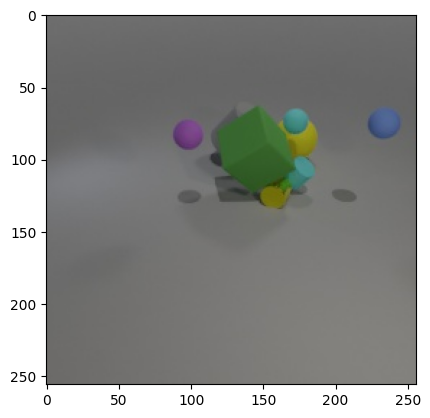

In [7]:
# 73, 1, 110, 210, 310, 410, 810, 1010, 1111, 2111, 2222, 3222
IDX =510
kubric_json = "/scratch-shared/dotero/kubric/annotations/train.json"
with open(kubric_json, 'r') as file:
    kubric_data = json.load(file)
    kubric_image_entry = kubric_data[IDX]

print(json.dumps(kubric_image_entry, indent=4))
import matplotlib.pyplot as plt
plt.imshow(plt.imread(kubric_image_entry["image_path"]))

In [ ]:
for i in [303, 1236, 2041, , 2536, 2871, 3040, 3210, 3360, 6721]:
    if kubric_data[i]["type"] == "touch":
        print(i, kubric_data[i]["type"])

303 touch
1236 touch
3210 touch


In [23]:
def save_kubric_images(idx, data):
    image_entry = data[idx]
    
    print(image_entry["type"])
    if image_entry["type"] == "touch":
        image = image_entry["image_path"]
        object1_mask_path = image_entry["object1_mask_path"]
        object2_mask_path = image_entry["object2_mask_path"]
        touch_mask = image_entry["target_path"]
        
    
        # original image 
        plt.imshow(plt.imread(image))
        plt.axis('off')
        plt.savefig(f"{idx}_ep_original.png", bbox_inches='tight', pad_inches=0, transparent=True)
        plt.show()
        
        # image with masks
        plt.imshow(plt.imread(image))
        plt.imshow(plt.imread(object1_mask_path), alpha=0.5, cmap=YELLOW_H_WHITE)
        plt.imshow(plt.imread(object2_mask_path ), alpha=0.5, cmap=BLUE_H_WHITE)
        plt.axis('off')
        plt.savefig(f"{idx}_ep_masks.png", bbox_inches='tight', pad_inches=0, transparent=True)
        plt.show()
        
        # # impage with POT
        plt.imshow(plt.imread(image))
        plt.imshow(plt.imread(touch_mask), alpha=0.5, cmap=GREEN_WHITE)
        plt.axis('off')
        plt.savefig(f"{idx}_ep_touch.png",bbox_inches='tight', pad_inches=0, transparent=True)
        plt.show()
        
        depth = compute_depth(plt.imread(image), guided_filter=False)
        plt.imshow(depth, cmap = 'inferno')
        plt.axis('off')
        plt.savefig(f"{idx}_ep_depth.png", bbox_inches='tight', pad_inches=0, transparent=True)
        plt.show()
        

100
no-touch
101
no-touch
102
no-touch
103
touch


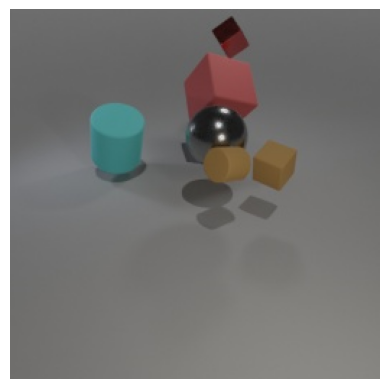

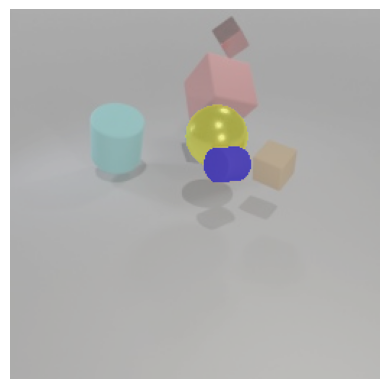

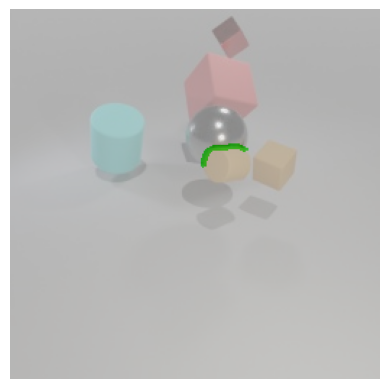

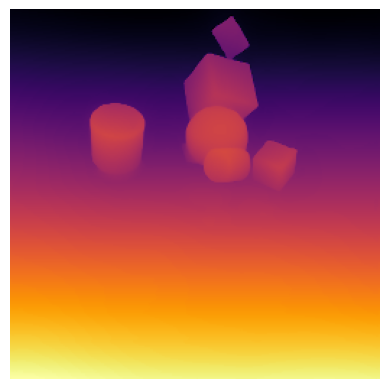

104
touch


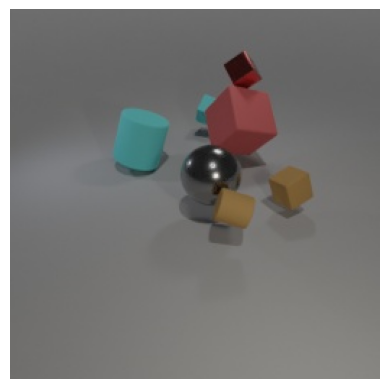

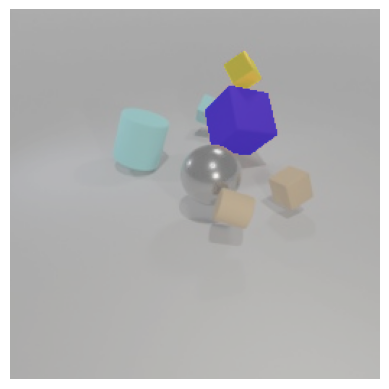

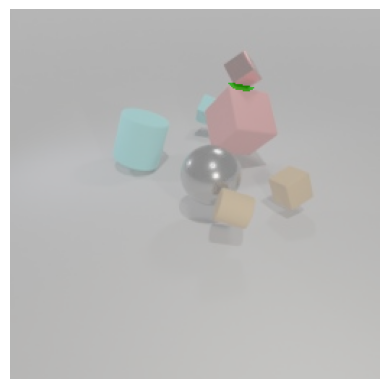

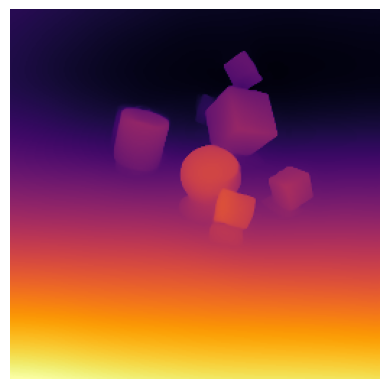

105
touch


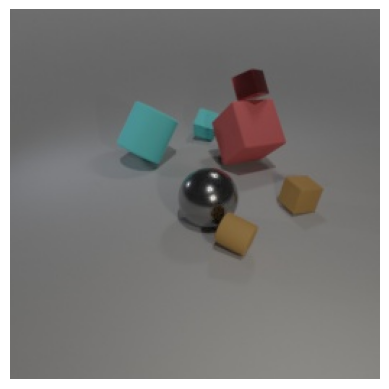

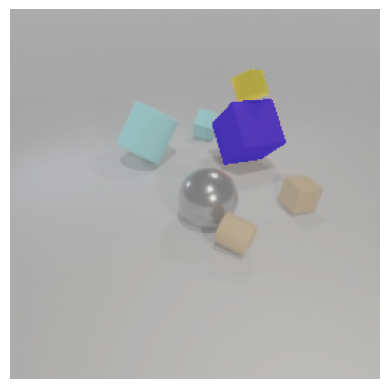

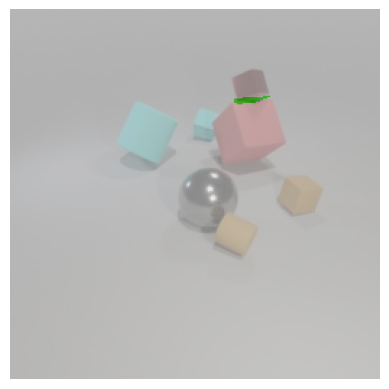

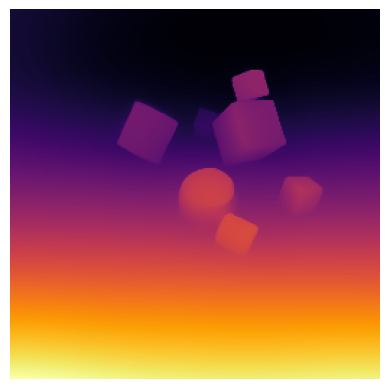

106
touch


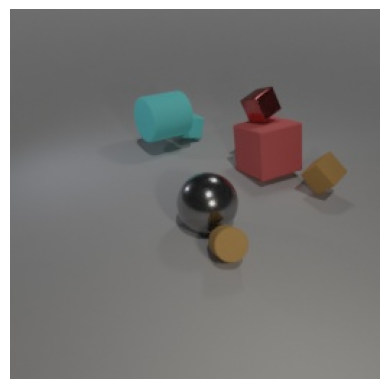

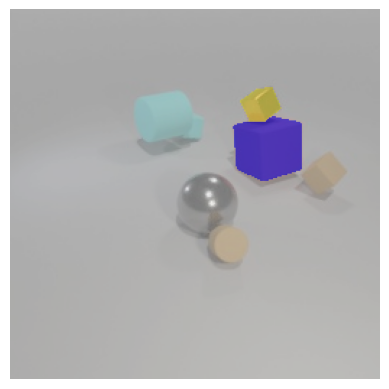

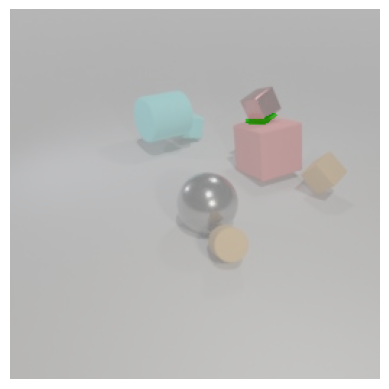

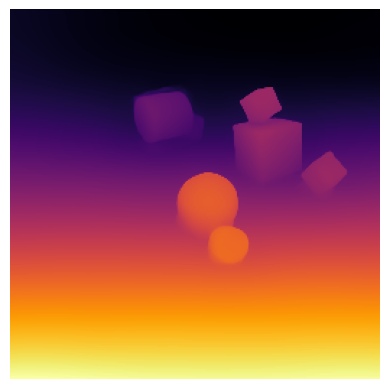

107
touch


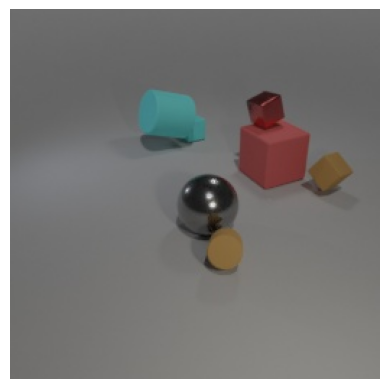

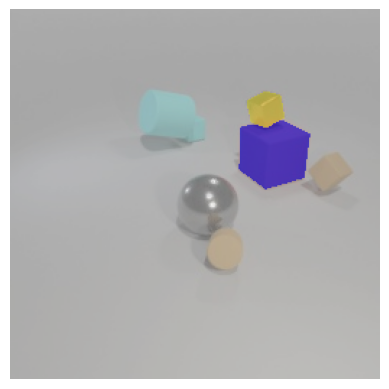

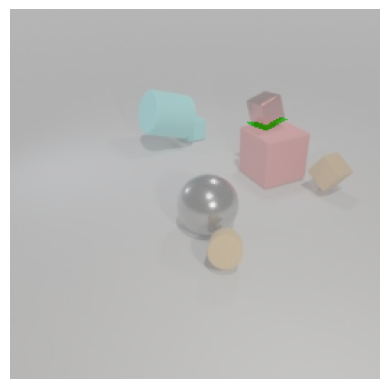

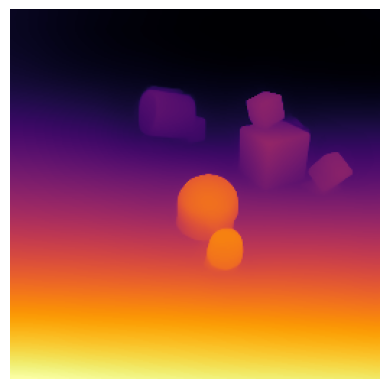

108
touch


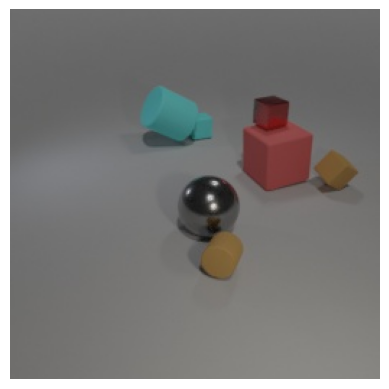

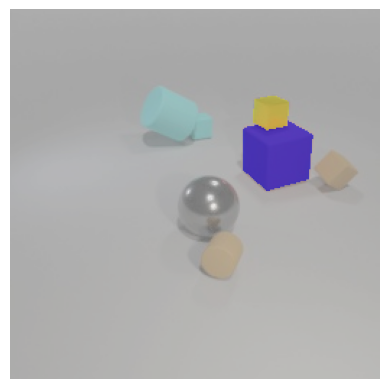

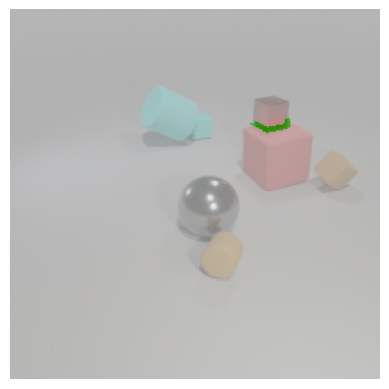

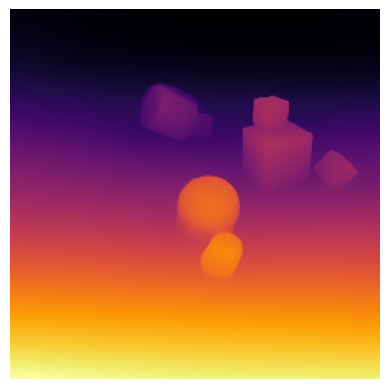

109
touch


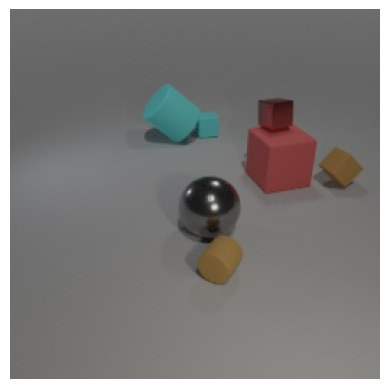

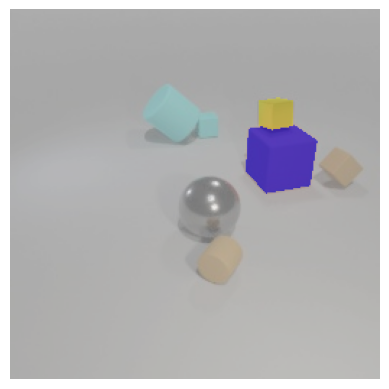

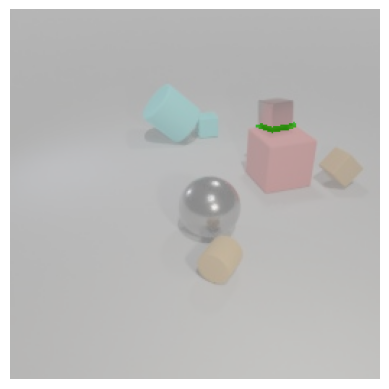

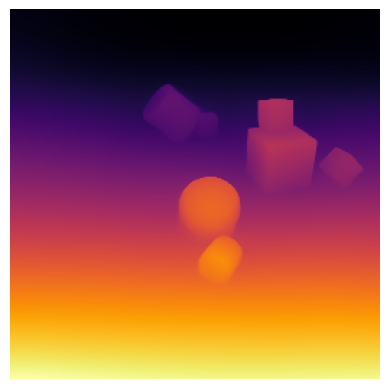

110
touch


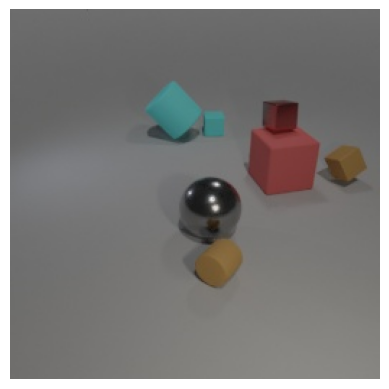

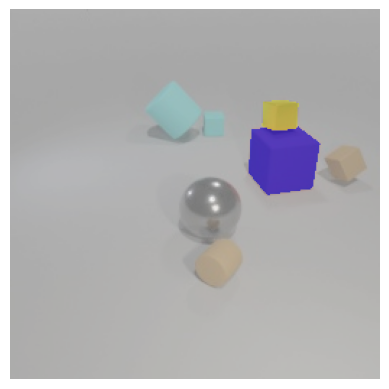

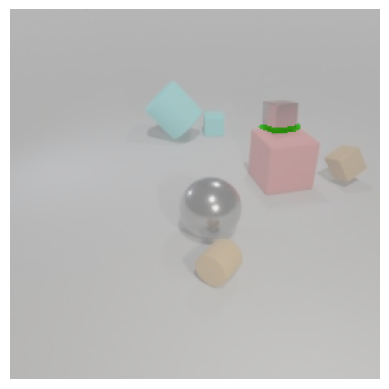

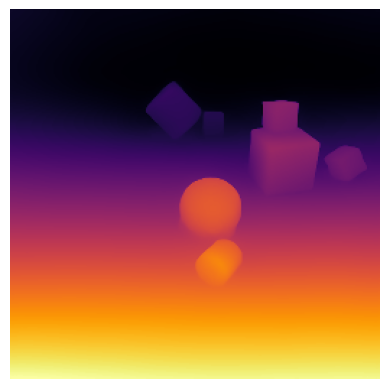

111
touch


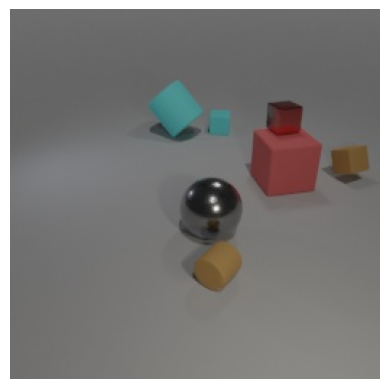

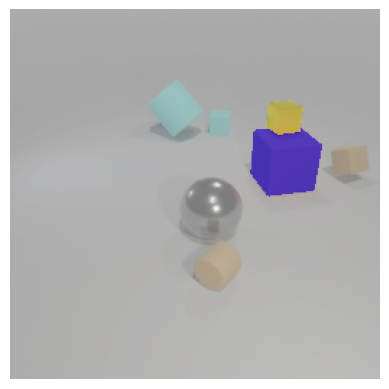

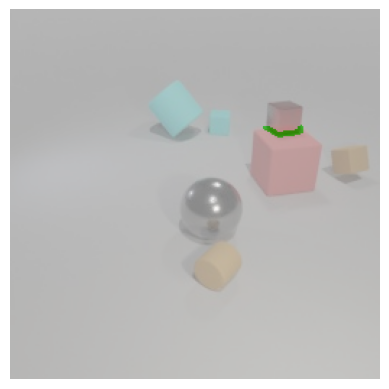

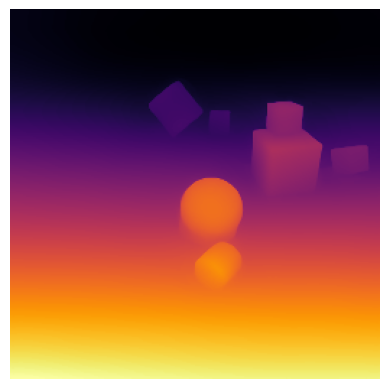

112
touch


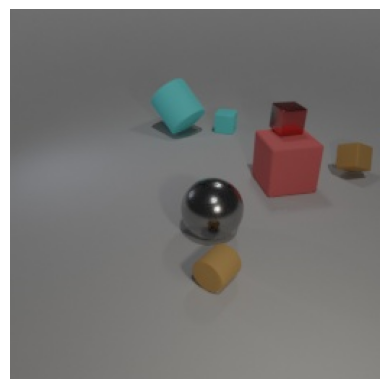

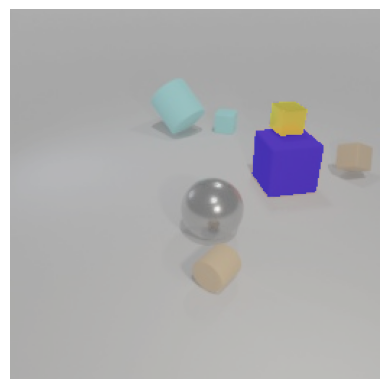

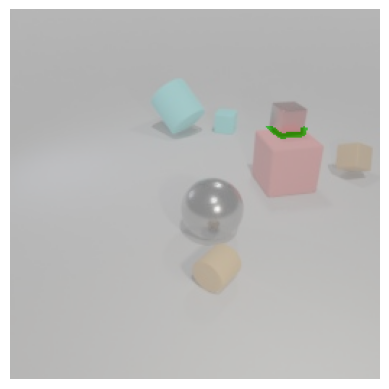

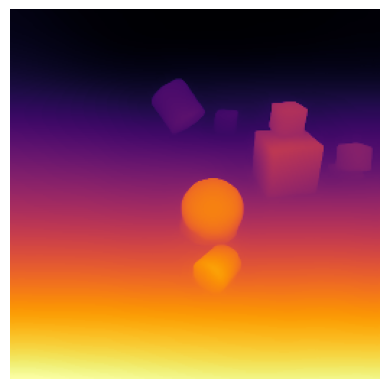

113
touch


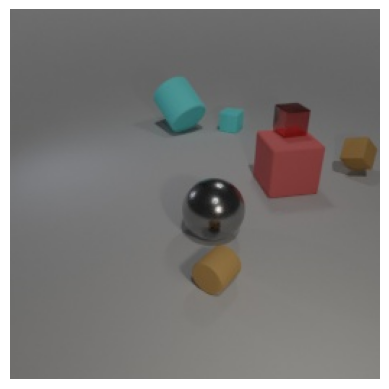

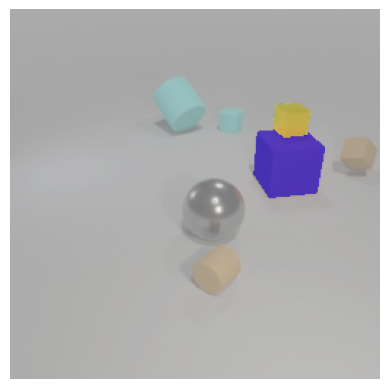

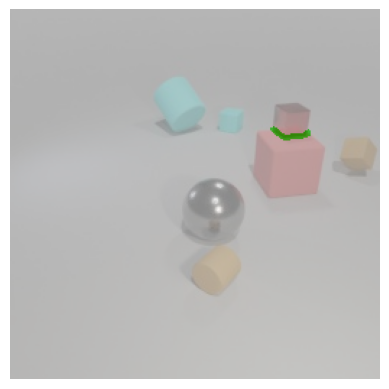

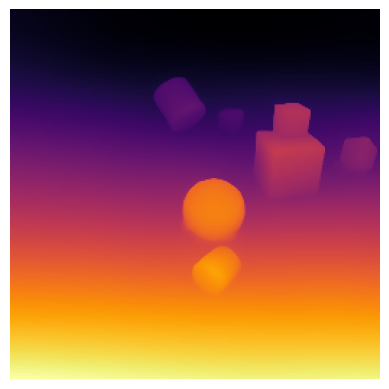

114
touch


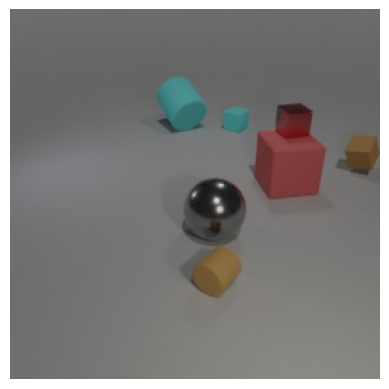

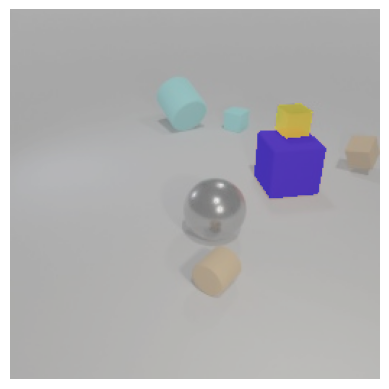

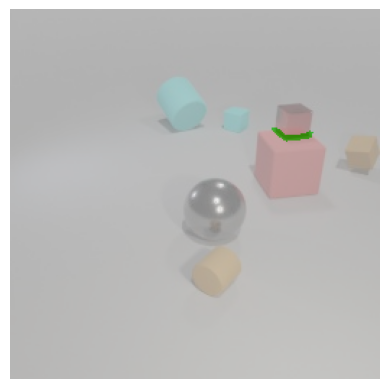

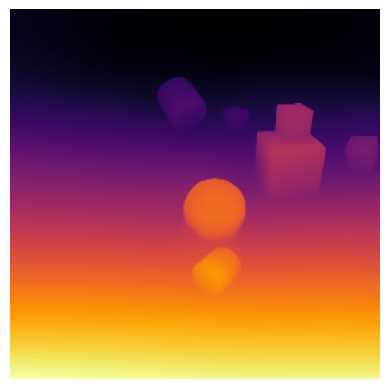

115
touch


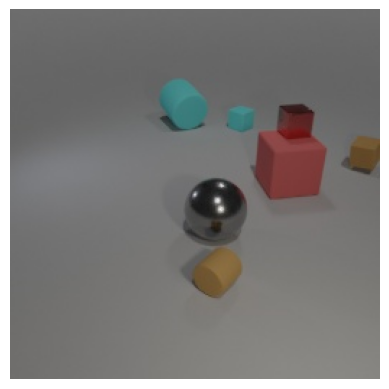

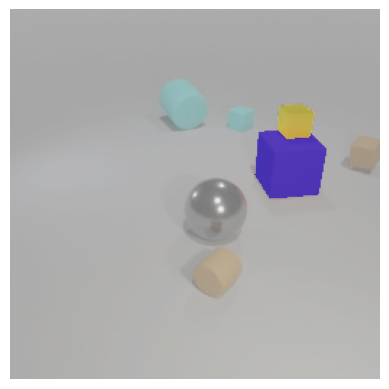

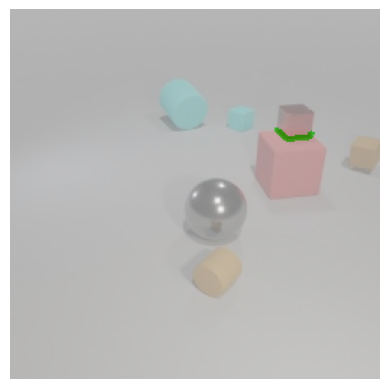

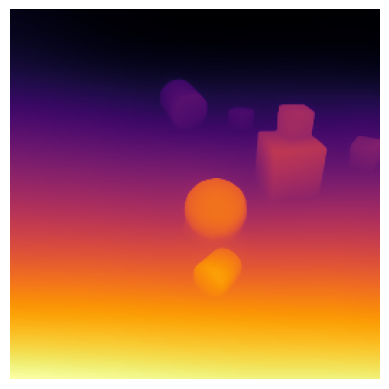

116
touch


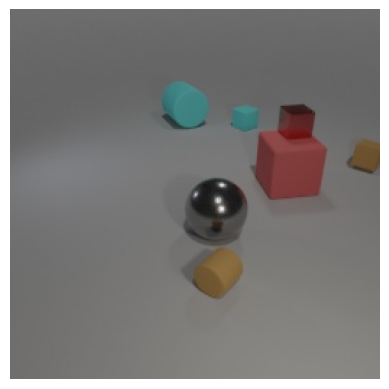

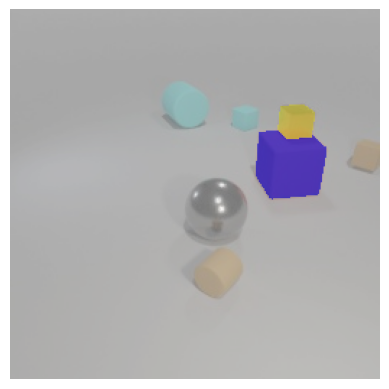

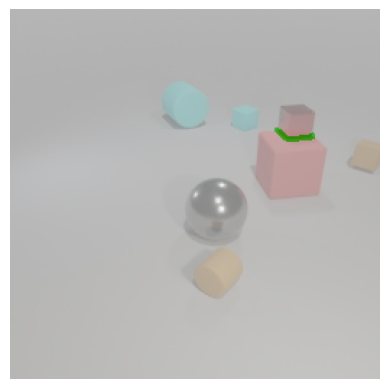

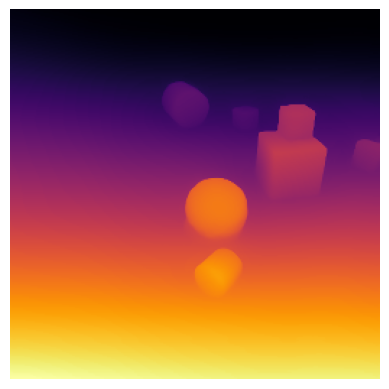

117
touch


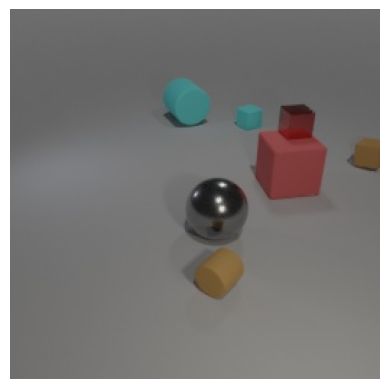

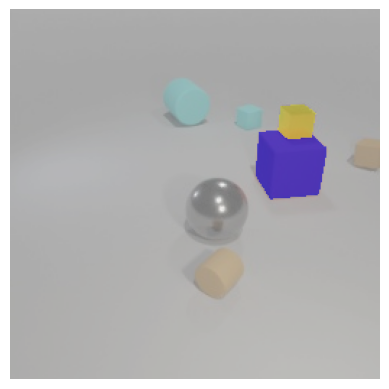

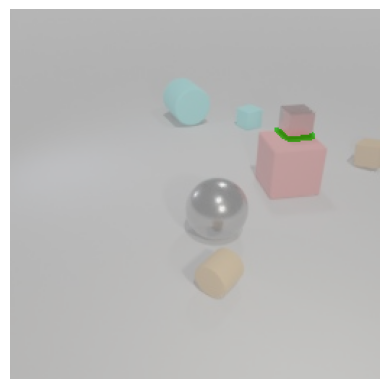

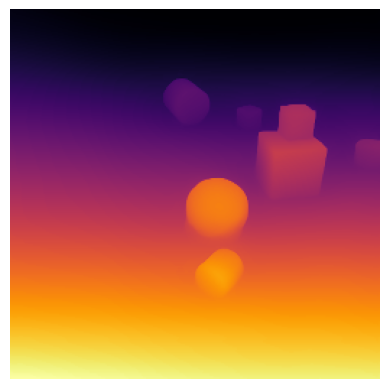

118
touch


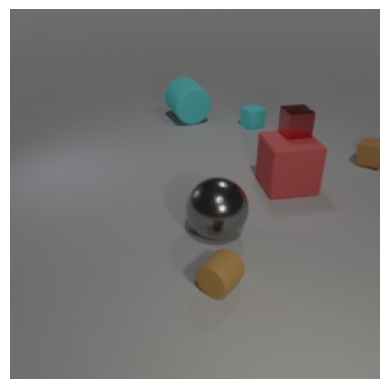

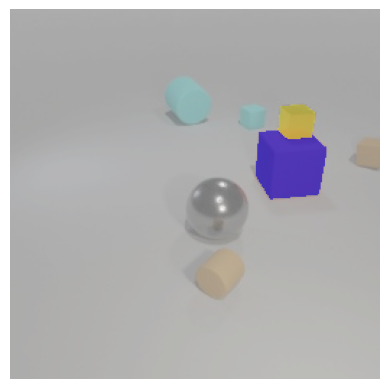

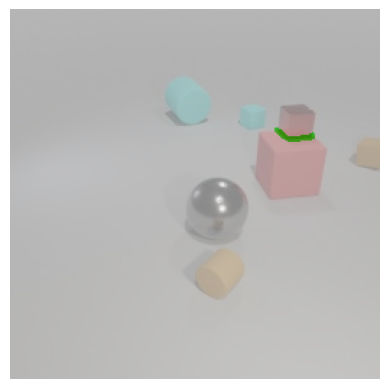

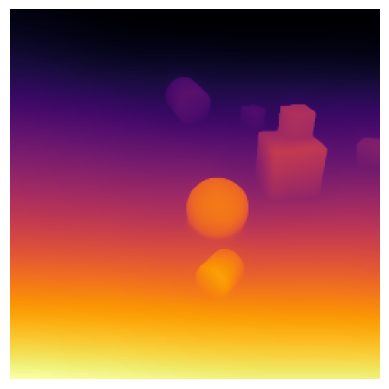

119
touch


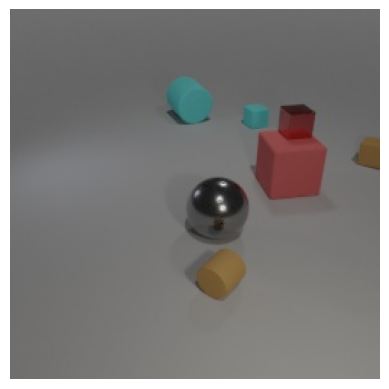

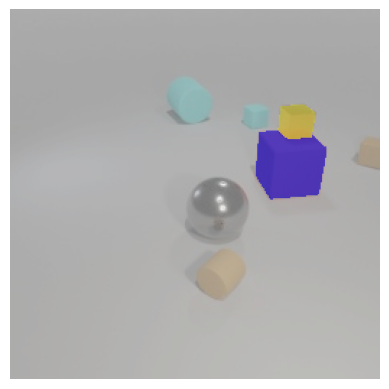

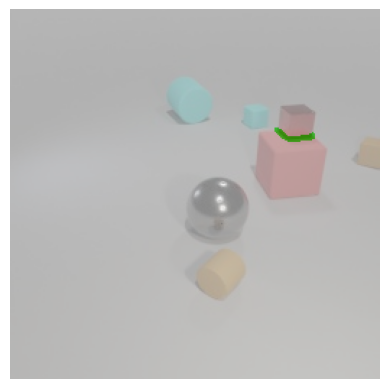

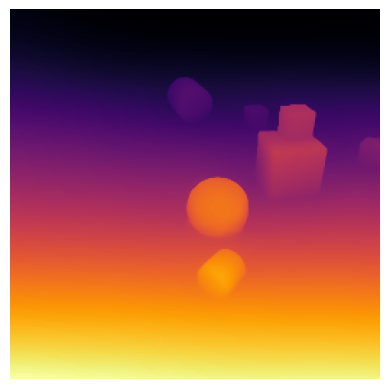

In [24]:
i = 3210
idx = 0
n_im = 0
for i in range(20):
    i += 100
    print(i)
    save_kubric_images(i, data = kubric_data)


In [4]:
print(len(kubric_data))

255431


In [6]:
kubric_json = "/scratch-shared/dotero/kubric_movi_a_256/annotations/val.json"
with open(kubric_json, 'r') as file:
    kubric_data = json.load(file)
    kubric_image_entry = kubric_data[IDX]
print(len(kubric_data))


5759
